# <center>  **<span style="font-size:80px;">Facephi Challenge</span>** </center>
# <center>  **<span style="font-size:50px;">Validación de documentos de identidad (DNI)</span>** </center>

In [96]:
import re
import cv2
import json
import difflib 
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
from datetime import datetime

from doctr.io import DocumentFile
from doctr.models import ocr_predictor
from collections import Counter

# Paths

In [97]:
DATA_DIR = Path("data")
DATA_DIR.mkdir(exist_ok=True)

TEMP_DIR = DATA_DIR / "temp"
TESTS_DIR = DATA_DIR / "tests"

TEMP_DIR.mkdir(exist_ok=True)
TESTS_DIR.mkdir(exist_ok=True)

# DNIError

In [98]:
class DNIError(Exception):
    """
    Excepción personalizada para fallos en el pipeline de validación.
    """

    AMARILLO = "\033[93m"
    RESET = "\033[0m"

    TIPOS = {
        "FORMATO":       {"msg": "Estructura de MRZ inválida.",             "color": AMARILLO},
        "DATO_INVALIDO": {"msg": "Dato extraído con formato corrupto.",     "color": AMARILLO},
        "INCOHERENCIA":  {"msg": "Discrepancia detectada entre VIZ y MRZ.", "color": AMARILLO},
    }

    def __init__(self, tipo_error, detalle=""):
        info = self.TIPOS.get(tipo_error, {"msg": "Error desconocido", "color": self.RESET})
        self.color = info["color"]
        self.mensaje_base = info["msg"]
        self.detalle = detalle
        
        msg = f"{self.color} [{tipo_error}]: {self.mensaje_base}{self.RESET} -> {self.detalle}"
        super().__init__(msg)

# Modelo OCR

In [99]:
model = ocr_predictor(pretrained=True, assume_straight_pages=True)

## Visual Inspection Zone (VIZ)

La extracción de datos en la cara frontal del DNI puede presentar desafíos críticos como: oclusiones, reflejos y fuentes variables. Nuestra clase `VIZProcessor` no se limita a una lectura OCR lineal, sino que también implementa una **estrategia de anclaje semántico**.


* **Anclas de Similitud (Fuzzy Matching):** Dado que el OCR puede confundir caracteres (ej. "NOMBRE" por "N0MBRE"), utilizamos `difflib` para localizar las etiquetas del documento mediante distancias de Levenshtein, asegurando que la extracción de datos sea resistente a errores de lectura.

* **Segmentación por Índices:** En lugar de confiar solo en Regex, delimitamos dinámicamente el espacio entre etiquetas (ej. entre 'APELLIDOS' y 'NOMBRE') para capturar cadenas de texto multilínea con precisión.

* **Limpieza de Ruido:** Filtra automáticamente elementos detectados erróneamente (como el DNI o número de soporte) que a veces el OCR puede mezclar con el nombre o los apellidos.

In [100]:
class VIZProcessor:
    """
    Procesador de la Zona de Inspección Visual (VIZ) para documentos de identidad.
    
    Esta clase se encarga de la extracción, limpieza y estructuración de datos 
    provenientes de un modelo OCR, utilizando técnicas de Fuzzy Matching para 
    identificar anclas de texto y expresiones regulares para datos deterministas.

    Attributes:
        model: Instancia del modelo OCR cargado.
        ANCHORS (list): Palabras clave esperadas en el documento para indexación.
        TRANS_MAP (dict): Mapa de traducción para normalizar caracteres especiales.
    """
    
    # Etiquetas estándar en el DNI para referenciar posiciones de datos
    ANCHORS = ["APELLIDOS", "NOMBRE", "SEXO", "NACIONALIDAD", "NUM SOPORTE", "NACIMIENTO", "VALIDEZ", "DNI"]
    
    # Normalización: Elimina tildes y 'ñ' para mejorar el matching
    TRANS_MAP = str.maketrans("ÁÉÍÓÚÑ", "AEIOUN")

    def __init__(self, model) -> None:
        """
        Inicializa el procesador con un modelo de visión específico.
        
        Args:
            model: Modelo de detección y reconocimiento de texto (OCR).
        """
        self.model = model
        self.full_text = ""
        self.result = None
        self.anch = {}  # Mapeo dinámico: {Etiqueta_Esperada: Texto_Detectado_OCR}

    def __str__(self) -> str:
        """Retorna una representación en mayúsculas y limpia del texto extraído."""
        if self.full_text:
            return "\n".join(self.full_text.split()).upper()
        return "VIZProcessor: Sin datos procesados."
    

    def _find_best_anchor(self, target: str, words: list[str]) -> str:
        """
        Utiliza el algoritmo de SequenceMatcher para encontrar la palabra más similar.
        
        Esto resuelve errores comunes del OCR como confundir una 'O' con un '0' 
        o una 'I' con un '1' en las etiquetas del documento.

        Args:
            target: La palabra ancla ideal (ej: "APELLIDOS").
            words: Lista de palabras detectadas por el OCR.

        Returns:
            str: La palabra de la lista con mayor ratio de similitud.
        """
        ratios = ((difflib.SequenceMatcher(None, target, w).ratio(), w) for w in words)
        return max(ratios, key=lambda x: x[0], default=(0, target))[1]

    def process_front(self, image_path: Path, word_confidence=0.5) -> dict[str, str]:
        """
        Realiza la lectura del anverso del documento y estructura la información.

        Args:
            image_path: Ruta local de la imagen.
            word_confidence: Umbral de confianza mínimo para aceptar un token.

        Returns:
            dict: Diccionario con campos 'dni', 'nombre', 'apellidos', etc.
        """

        # Lectura del documento
        doc = DocumentFile.from_images(image_path)
        self.result = self.model(doc)

        # Procesamiento de texto
        raw_lines = [
            " ".join(w.value for w in line.words if w.confidence > word_confidence).upper()
            for page in self.result.pages 
            for block in page.blocks 
            for line in block.lines
        ]

        # Normalización del texto (Eliminación de tildes y ruidos)
        self.full_text = " ".join(filter(None, raw_lines))
        clean_viz = self.full_text.translate(self.TRANS_MAP)
        words = clean_viz.split()

        # Localización dinámica de anclas (Fuzzy Matching)
        self.anch = {a: self._find_best_anchor(a, words) for a in self.ANCHORS}

        structured_data = {}

        # ---------------------------------------------------------
        # EXTRACCIÓN MEDIANTE PATRONES DETERMINISTAS (RegEx)
        # ---------------------------------------------------------
        
        # DNI: Formato estándar 8 dígitos + letra de control (ej: 99999999R)
        dni_match = re.search(r"\b\d{8}[A-Z]\b", clean_viz)
        structured_data["dni"] = dni_match.group(0) if dni_match else None

        # Número de Soporte: Identificador de la tarjeta (ej: CAA000000)
        soporte_match = re.search(r"\b[A-Z]{3}\d{6}\b", clean_viz)
        structured_data["soporte"] = soporte_match.group(0) if soporte_match else None

        # Fechas: Extracción general de cualquier formato DD MM AAAA
        fechas = re.findall(r"\b\d{2}\s\d{2}\s\d{4}\b", clean_viz)
        structured_data["nacimiento"] = fechas[0] if len(fechas) > 0 else None
        structured_data["validez"] = fechas[1] if len(fechas) > 1 else None

        # Sexo: M o F aislada
        sexo_match = re.search(r"\b([MF])\b", clean_viz)
        structured_data["sexo"] = sexo_match.group(1) if sexo_match else None

        # Nacionalidad: Tres mayúsculas
        # Filtramos palabras del documento para no confundir
        nacionalidades = re.findall(r"\b([A-Z]{3})\b", clean_viz)
        nac_validas = [n for n in nacionalidades if n not in ["DNI", "SEX", "NUM", "MEN", "HEN"]] # MEN / HEN (sólo para especimenes)
        structured_data["nacionalidad"] = nac_validas[0] if nac_validas else None

        # ---------------------------------------------------------
        # EXTRACCIÓN MEDIANTE POSICIONAMIENTO RELATIVO (Slice de Texto)
        # ---------------------------------------------------------
        
        # Encontramos en qué posición de la cadena está cada ancla
        idx_apellidos = clean_viz.find(self.anch["APELLIDOS"])
        idx_nombre = clean_viz.find(self.anch["NOMBRE"])
        
        # APELLIDOS: Todo lo que esté entre la etiqueta "APELLIDOS" y la etiqueta "NOMBRE"
        if idx_apellidos != -1 and idx_nombre != -1 and idx_nombre > idx_apellidos:
            apellidos_str = clean_viz[idx_apellidos + len(self.anch["APELLIDOS"]):idx_nombre].strip()
            # Limpieza si el OCR intercaló el DNI o NÚMERO DE SOPORTE dentro de esta zona
            apellidos_str = re.sub(r"\b(\d{8}[A-Z]|[A-Z]{3}\d{6})\b", "", apellidos_str).strip()
            structured_data["apellidos"] = apellidos_str or None

        # NOMBRE: Todo lo que esté entre "NOMBRE" y las siguientes etiquetas (SEXO, NACIONALIDAD o NACIMIENTO)
        if idx_nombre != -1:
            limites_posibles = []
            for ancla in [self.anch["SEXO"], self.anch["NACIONALIDAD"], self.anch["NACIMIENTO"]]:
                idx = clean_viz.find(ancla)
                if idx > idx_nombre:
                    limites_posibles.append(idx)
            
            if limites_posibles:
                # Cortamos en la etiqueta lógica que haya caído más cerca después del nombre
                limite_mas_cercano = min(limites_posibles)
                nombre_str = clean_viz[idx_nombre + len(self.anch["NOMBRE"]):limite_mas_cercano].strip()
            else:
                # Si el OCR no detectó más etiquetas, agarramos la siguiente palabra
                nombre_str = " ".join(clean_viz[idx_nombre + len(self.anch['NOMBRE']):].split()[:1])
            
            # Limpiamos letras aisladas (en caso de lectura errónea)
            nombre_str = re.sub(r"\b[A-Z]\b", "", nombre_str).strip()
            structured_data["nombres"] = nombre_str or None

        return structured_data
    
    def show(self):
        """Renderiza visualmente el resultado del OCR si el modelo lo soporta."""
        if self.result:
            self.result.show()
        else:
            print("No hay resultados para mostrar. Ejecute 'process_front' primero.")

### Results


--- RESULTADO DEL OCR ---
dni           : 99999999R
soporte       : CAA000000
nacimiento    : 01 01 1980
validez       : 02 06 2021
sexo          : F
nacionalidad  : ESP
apellidos     : ESPANOLA HEN ESPANOLA
nombres       : CARMEN

--- FULL VIZ DATA ---
REINO
DE
ESPANA
ES
DOCUMENTO
NACIONAL
DEIDENTIDAD
CAA000000
99999999R
DNI
99999999R
APELLIDOS
ESPANOLA
HEN
ESPANOLA
NOMBRE
CARMEN
SEYO
NACIONALIDAD
C
NACIMIENTO
OPECRT
F
ESP
01
01
1980
EMISION
VAUIOLZ
02
06
2021
02
06
2031
NUM
SOPORTI
020631
CAA000000
HMLU
987654
DOCUMENTONACIONAL
DE
IDENTIDAD
/
NATIONAL
IDENTITY
-
CARD

--- MOSTRANDO IMAGEN... ---


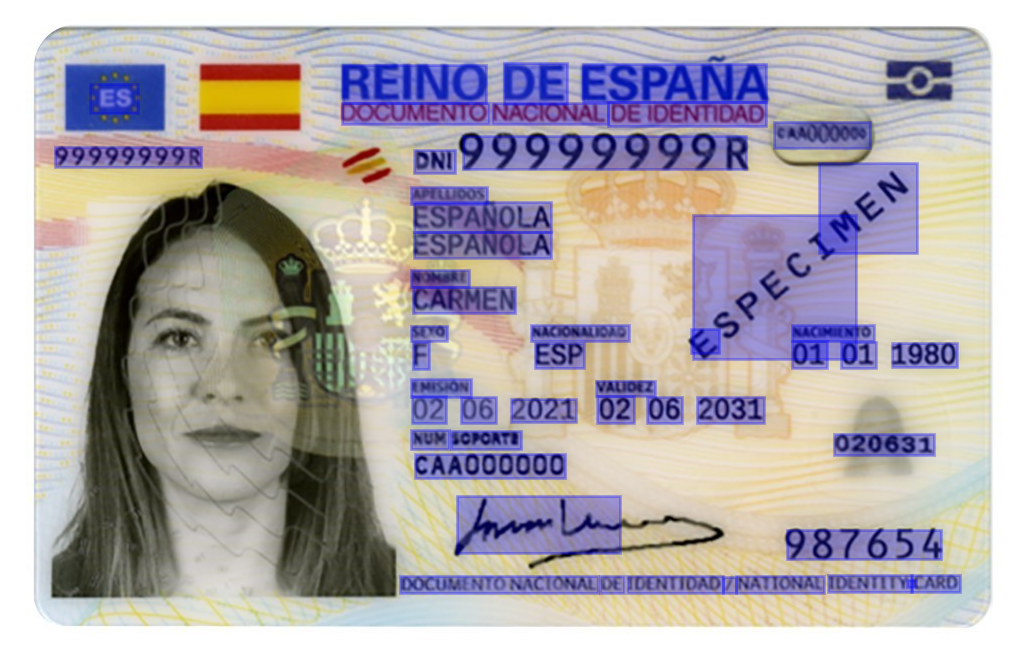

In [101]:
viz = VIZProcessor(model)
viz_data = viz.process_front(TESTS_DIR / "especimen" / "front.jpg", word_confidence=0.1)

print("\n--- RESULTADO DEL OCR ---")
for key, val in viz_data.items():
    print(f"{key:<14}: {val}")

print("\n--- FULL VIZ DATA ---")
print(viz)

print("\n--- MOSTRANDO IMAGEN... ---")
viz.show()

## Machine Readable Zone (MRZ)

Nuestro núcleo de la detección es la MRZ. Debido a que un solo error de lectura en esta zona invalida todo el documento, hemos diseñado un sistema inspirado en arquitecturas de Redes Neuronales Convulcionales (CNN).

* **Simulación de Monte Carlo:** El sistema no realiza una sola lectura. Realiza $N$ iteraciones de la imagen aplicando ***Data Augmentation*** (variaciones de brillo, contraste y ruido). Mediante un **voto por mayoría** a nivel de carácter, el sistema converge hacia la cadena más probable, eliminando errores aleatorios del OCR.

* **Mapas de Familia de Caracteres:** Aplicamos máscaras de tipado estricto (Numérico, Alfabético o Alpha-Numérico) según el estándar ICAO. Si el OCR lee una "O" en un campo de fecha, el sistema la traduce automáticamente a "0" basándose en la máscara de familia.

* **Filtro Base:** Se preprocesa la imagen para maximizar el contraste de los caracteres frente al fondo de seguridad del DNI, facilitando la segmentación.

In [102]:
class MRZProcessor:
    """
    Procesador avanzado de MRZ (Machine Readable Zone) diseñado para alta resiliencia.
    
    A diferencia de un OCR lineal, este sistema aplica un enfoque inspirado en 
    Redes Neuronales Convolucionales (CNN) y simulaciones de Monte Carlo: 
    genera múltiples 'percepciones' de la misma imagen mediante aumentación de datos 
    y resuelve la incertidumbre mediante un sistema de votación por mayoría.
    """

    def __init__(self, model) -> None:
        """
        Configura los mapas de caracteres y máscaras de estructura oficial ICAO.
        
        Attributes:
            masks: Define la semántica de cada posición en el DNI.
            family_map: Mapea cada máscara a un tipo de dato (Alpha, Numeric, X/Any).
            to_num/to_alpha: Tablas de corrección para errores comunes de forma (OCR Confusions).
        """
        self.model = model

        # Estructura del estándar ICAO para documentos tamaño tarjeta de crédito (TD1)
        self.masks = {
            1: "aabbbcccddddddefffffffffffffff",
            2: "gggggghijjjjjjknnnmmmmmmmmmmmp", 
            3: "oooooooooooooooooooooooooooooo"
        }

        self.family_map = {
            'a': 'A', 'b': 'A', 'c': 'A', 'd': 'N', 'e': 'N', 'f': 'X',
            'g': 'N', 'h': 'N', 'i': 'A', 'j': 'N', 'k': 'N', 'n': 'A', 'm': 'X', 'p': 'N',
            'a': 'A', 'b': 'A', 'c': 'A', 'd': 'N', 'e': 'N', 'f': 'X', 'o': 'A'
        }
        self.to_num = str.maketrans({
            'O': '0', 'Q': '0', 'U': '0', 'D': '0', 
            'I': '1', 'L': '1', 'J': '1',
            'Z': '2', 'A': '4', 'S': '5', 'G': '6',
            'B': '8', 'T': '7'
        })
        self.to_alpha = str.maketrans({
            '0': 'O', '1': 'I', '2': 'Z', '4': 'A',
            '5': 'S', '8': 'B', '7': 'T', '6': 'G'
        })


    def _preprocess_basic(self, image_path: Path) -> np.ndarray:
        """
        Preprocesamiento determinista: Mejora el contraste local (CLAHE).
        
        Utiliza Contrast Limited Adaptive Histogram Equalization para normalizar 
        la iluminación sin amplificar el ruido en las zonas de texto.
        """
        img = cv2.imread(image_path)
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
        return clahe.apply(gray)
    
    def _apply_augmentation(self, img: np.ndarray) -> np.ndarray:
        """
        Genera variaciones de la imagen mediante transformaciones afines y de intensidad.
        Evita el ruido destructivo para preservar la tipografía OCR-B del MRZ.
        """
        aug = img.copy()
        h, w = aug.shape[:2]

        # 1. Variación de iluminación (CLAHE con parámetros aleatorios o Gamma)
        # Esto simula fotos con flash o sombras
        gamma = np.random.uniform(0.7, 1.5)
        inv_gamma = 1.0 / gamma
        table = np.array([((i / 255.0) ** inv_gamma) * 255 for i in np.arange(0, 256)]).astype("uint8")
        aug = cv2.LUT(aug, table)

        # 2. Ligeras rotaciones (simula mal encuadre)
        # Rotamos entre -2 y 2 grados. Más que eso suele hacer que el OCR falle la detección de línea.
        angle = np.random.uniform(-2, 2)
        M = cv2.getRotationMatrix2D((w/2, h/2), angle, 1.0)
        # Rellenamos los bordes con blanco o gris claro (color típico del fondo del DNI)
        aug = cv2.warpAffine(aug, M, (w, h), borderMode=cv2.BORDER_REPLICATE)

        # 3. Desenfoque Gaussiano muy ligero (simula cámara desenfocada)
        # Solo lo aplicamos a veces (50% de probabilidad)
        if np.random.rand() > 0.5:
            # Kernel 3x3 es suficiente para crear incertidumbre sin destruir la letra
            aug = cv2.GaussianBlur(aug, (3, 3), 0)

        # 4. Operaciones morfológicas leves (simula grosor variable de tinta/impresión)
        # 50% de probabilidad de hacer la letra más fina (erosión de la imagen, dilatación del texto oscuro)
        elif np.random.rand() > 0.5:
            kernel = np.ones((2, 2), np.uint8)
            aug = cv2.dilate(aug, kernel, iterations=1) # Engrosa las zonas oscuras (texto)

        return aug

    def get_mrz_montecarlo(self, image_path: Path, path: Path, iterations=5) -> list[str]:
        """
        Utiliza un enfoque Monte Carlo para converger en la cadena de texto más probable. 
        
        Al igual que una CNN extrae características mediante múltiples filtros (kernels),
        generamos múltiples activaciones de texto. Utilizamos un sistema de voto por mayoría
        para corregir omisiones de caracteres (como AA -> A) y ruidos visuales.
        """
        img_orig = None
        all_samples = [] 

        for i in range(iterations):
            name = "mrz_base" if i == 0 else f"mrz_aug_{i}"
            base_path = TEMP_DIR / path
            base_path.mkdir(exist_ok=True, parents=True)
            
            aug_path = base_path / f"{name}.jpg"
            json_path = base_path / f"{name}.json"
            
            # Si la iteración ya fue procesada, cargamos el resultado del JSON
            if json_path.exists():
                with open(json_path, 'r') as f:
                    lines = json.load(f)
                all_samples.append(lines)
                continue
            
            # Aplicación de filtros según la iteración
            if not aug_path.exists():
                if i == 0:
                    processed = self._preprocess_basic(str(image_path))
                    cv2.imwrite(str(aug_path), processed)
                else:
                    if img_orig is None:
                        img_orig = cv2.imread(str(image_path))
                    aug_img = self._apply_augmentation(img_orig)
                    cv2.imwrite(str(aug_path), aug_img)

            # Inferencia del modelo OCR
            doc = DocumentFile.from_images(aug_path)
            result = self.model(doc)
            
            # Extracción y limpieza básica de las líneas del bloque MRZ
            lines = []
            for page in result.pages:
                for block in page.blocks:
                    for line in block.lines:
                        text = "".join([w.value for w in line.words]).upper().replace(" ", "")
                        lines.append(text)
            
            # Guardamos las últimas 3 líneas detectadas
            if len(lines) >= 3:
                extracted = lines[-3:]
                all_samples.append(extracted) 
                with open(json_path, "w") as f:
                    json.dump(extracted, f)

        mrz_lines = self._majority_vote(all_samples)
        return mrz_lines
    
    def _majority_vote(self, all_samples: list[list[str]]) -> list[str]:
        """
        Consolida múltiples inferencias en un resultado único mediante colapso estadístico.
        
        Este método implementa una votación a nivel de carácter (Character-level Voting).
        Al analizar la moda estadística de cada posición de la cadena, el sistema es 
        capaz de auto-corregir errores aleatorios de segmentación o ruidos visuales 
        que solo aparecen en algunas de las muestras.

        Args:
            all_samples: Matriz de dimensiones (N_muestras x 3_líneas x 30_caracteres).

        Returns:
            list[str]: Las 3 líneas del MRZ tras el proceso de consenso y limpieza.
        """
        final_mrz = []
        
        # Iteramos sobre las 3 líneas estándar del formato TD1
        for line_idx in range(3):
            voted_line = ""
            
            # El estándar ICAO TD1 define una longitud fija de 30 caracteres por línea
            for char_idx in range(30):
                chars_at_pos = []
                
                # Recolectamos el carácter que detectó cada muestra en la posición actual
                for sample in all_samples:
                    # Verificación de seguridad por si una muestra tiene longitud insuficiente
                    if char_idx < len(sample[line_idx]):
                        chars_at_pos.append(sample[line_idx][char_idx])
                
                if chars_at_pos:
                    # Voto por mayoría: Counter().most_common(1) devuelve [(carácter, frecuencia)]
                    # Obtenemos el elemento con mayor frecuencia (la moda)
                    most_common = Counter(chars_at_pos).most_common(1)[0][0]
                    voted_line += most_common
                else:
                    # Carácter de relleno por defecto si no hay datos en ninguna muestra
                    voted_line += "<"
            
            # Postprocesamiento: Aplicamos correcciones de familia (Alpha vs Num) 
            # basándonos en la estructura conocida del documento.
            final_mrz.append(self._clean_line(voted_line, line_idx + 1))
            
        return final_mrz


    def _clean_line(self, text: str, line_num: int) -> str:
        """
        Normaliza y corrige una línea de MRZ basándose en su posición y máscara.
        
        Aplica correcciones de tipo (Numérico vs Alfabético) para resolver confusiones 
        comunes del OCR y realiza una limpieza de ruido específica para la línea de identidad.

        Args:
            text: Texto crudo extraído por el OCR o el sistema de votos.
            line_num: Número de línea (1, 2 o 3) para aplicar la máscara correcta.

        Returns:
            str: Línea de 30 caracteres normalizada y validada.
        """
        mask = self.masks.get(line_num, "X" * 30)
        text = text.upper().replace(" ", "<")
        cleaned = ""
        for i in range(30):
            char = text[i] if i < len(text) else "<"
            family = self.family_map.get(mask[i], 'X')
            if family == "N": cleaned += char.translate(self.to_num)
            elif family == "A": cleaned += char.translate(self.to_alpha)
            else: cleaned += char
        
    
        # Limpieza especial para la línea de nombres y apellidos
        if line_num == 3:
            # Eliminamos letras huérfanas al final producidas por ruido visual (<X<<)
            cleaned = re.sub(r'<+[A-Z]{1, 2}<+$', lambda m: "<" * len(m.group(0)), cleaned)
            cleaned = cleaned.ljust(30, "<")[:30]
            
        return cleaned
    
    @staticmethod
    def mrz_structured_data(mrz_lines: list[str]) -> dict[str, str]:
        """
        Desglosa las líneas MRZ (formato TD1) en campos de información legible.

        Args:
            mrz_lines: Las 3 líneas ya validadas del MRZ.

        Returns:
            dict: Datos formateados (DNI, fechas, nombres, nacionalidad, etc.).

        Raises:
            DNIError: Si no se ha conseguido extraer una fecha válida.
        """
        line1, line2, line3 = mrz_lines
        
        # Tratamiento de Nombres (Línea 3)
        # Formato: APELLIDO1<APELLIDO2<<NOMBRE1<NOMBRE2<<<<
        parts = line3.strip("<").split("<<")
        apellidos = parts[0].replace("<", " ") if len(parts) > 0 else ""
        nombres = parts[1].replace("<", " ") if len(parts) > 1 else ""

        # Tratamiento de Fechas (Línea 2)
        # Formato YYMMDD
        birth_yy, birth_mm, birth_dd = line2[0:2], line2[2:4], line2[4:6]
        expiry_yy, expiry_mm, expiry_dd = line2[8:10], line2[10:12], line2[12:14]
        
        # Inferir siglo de nacimiento (si el año es mayor al año actual, nació en los 1900s)
        current_year_2_digits = datetime.now().year % 100

        # Si no se ha conseguido obtener la fecha
        try: 
            birth_century = "19" if int(birth_yy) > current_year_2_digits else "20"
        except: 
            raise DNIError("DATO_INVALIDO", f"Año de nacimiento '{birth_yy}' no es convertible a entero.")

        birth_date_fmt = f"{birth_dd}/{birth_mm}/{birth_century}{birth_yy}" if birth_yy.isdigit() else None
        expiry_date_fmt = f"{expiry_dd}/{expiry_mm}/20{expiry_yy}" if expiry_yy.isdigit() else None

        return {
            "tipo":         line1[0:2].replace("<", ""),  
            "pais":         line1[2:5].replace("<", ""),
            "soporte":      line1[5:14].replace("<", ""),
            "dni":          line1[15:24].replace("<", ""),

            "nacimiento":   birth_date_fmt,
            "sexo":         line2[7].replace("<", "INDEFINIDO"),
            "validez":      expiry_date_fmt,
            "nacionalidad": line2[15:18].replace("<", ""),
           
            "apellidos":    apellidos,
            "nombre":       nombres
        }


## CrossValidation

Nuestro sistema de validación de identidad no es fiable si analiza las caras del documento como entes aislados. Por tanto, la clase `CrossValidation` actúa como el árbitro de integridad del sistema.

* **Detección de Manipulación:** Al contrastar los nombres y apellidos extraídos de la cara frontal (VIZ) con los codificados en la MRZ, podemos detectar discrepancias que indicarían un documento alterado o un error grave de lectura.

* **Reconstrucción Teórica:** El algoritmo reconstruye cómo *debería* ser la línea 3 de la MRZ basándose en el frontal. Si la similitud supera el umbral crítico ($ratio > 0.7$), el sistema corrige automáticamente errores de duplicación de caracteres que suelen ocurrir en el OCR de la MRZ.

* **Normalización de Fechas:** Unifica los formatos DD/MM/AAAA del frontal con el formato YYMMDD del reverso para una comparación lógica.

In [103]:
class CrossValidation:
    """
    Clase de utilidad para la validación cruzada y consolidación de datos.
    
    Aplica reglas de negocio para verificar la integridad de las líneas MRZ y 
    cruza la información con la Zona de Inspección Visual (VIZ) para corregir 
    discrepancias, especialmente en nombres y apellidos.
    """
    def __init__(self, mrz_raw_lines: list[str], mrz_raw_structured: dict[str, str],
                  viz_raw_structured: dict[str, str], confidence_threshold=0.7) -> tuple[list[str], dict[str, str]]:
       
        self.mrz_raw_lines = mrz_raw_lines
        self.mrz_raw_structured = mrz_raw_structured
        self.viz_raw_structured = viz_raw_structured
        self.confidence_threshold = confidence_threshold    



    def cross_validate_and_merge(self):
        """
        Ejecuta el pipeline completo de validación y limpieza de líneas MRZ.

        Args:
            mrz_lines: Lista de las 3 líneas extraídas del MRZ.
            viz_data: Diccionario de datos estructurados provenientes del VIZProcessor.
            confidence_threshold: Umbral de similitud (0-1) para aceptar correcciones del VIZ.

        Returns:
            tuple: Líneas MRZ corregidas y diccionario de datos finales.
        
        Raises:
            DNIError: Si el MRZ no contiene las 3 líneas mínimas requeridas.
        """
        # Trabajamos sobre una copia para no mutar el original prematuramente
        mrz_lines = list(self.mrz_raw_lines)

        if len(mrz_lines) < 3:
            raise DNIError(tipo_error="FORMATO", detalle="MRZ ha detectado menos de 3 líneas")

        mrz_lines[0] = self._check_line1(mrz_lines[0])
        mrz_lines[1] = self._check_line2(mrz_lines[1])
        mrz_lines[2] = self._check_line3(mrz_lines[2])

        return mrz_lines

    
    def _check_line1(self, raw_line_1: str):
        """
        Limpia la línea 1 y valida el número de documento con el VIZ.
        """
        line = list(raw_line_1) 
        
        # DNI match
        viz_dni = self.viz_raw_structured.get("dni")
        mrz_dni = self.mrz_raw_structured.get("dni")

        ratio = difflib.SequenceMatcher(None, viz_dni, mrz_dni).ratio() 
        if ratio < self.confidence_threshold:
            raise DNIError("INCOHERENCIA", detalle=f"Datos del DNI no coincidentes entre VIZ y MRZ: {viz_dni} y {mrz_dni}")
                

        # Si no es letra ni número, forzamos a '<'
        for i in range(30):
            if not line[i].isalnum(): 
                line[i] = '<'

        # Nada más empezar un '<', lo siguiente es todo '<'
        # Empezamos a mirar en la zona de datos opcionales (índice 15)
        found_padding = False
        for i in range(24, 30):
            if line[i] == '<':
                found_padding = True
            elif found_padding:
                # Si ya empezó el relleno y encontramos una letra/número errante, lo borramos
                line[i] = '<'

        return "".join(line)
    
    def _check_line2(self, raw_line_2: str):
        line = list(raw_line_2)
        for i in range(30):
            if not line[i].isalnum(): 
                line[i] = '<'

        # '<' hasta el último carácter que es un número
        # Rescatamos el último dígito numérico que leyó el OCR en la parte final
        last_digit = '-1' # Valor por defecto por seguridad
        for i in range(29, 15, -1):
            if line[i].isdigit():
                last_digit = line[i] # encontramos el último (primero en el bucle) número
                break
                
        # En el DNI desde el índice 18 hasta el 28 todo es relleno '<'
        for i in range(18, 29):
            line[i] = '<'
            
        # Colocamos el dígito rescatado exactamente en la última posición (índice 29)
        line[29] = last_digit
        return "".join(line)
    
    def _check_line3(self, raw_line_3: str):
        """
        Aplica validación cruzada entre la MRZ y la zona VIZ (frontal) del documento.
        Reconstruye cómo debería ser la línea 3 del MRZ teóricamente usando los datos 
        estructurados de la clase VIZProcessor.
        Si la similitud con la lectura real supera el umbral de confianza, corrige la MRZ.
        """
        viz_data = self.viz_raw_structured
        confidence_threshold = self.confidence_threshold
        line = raw_line_3

        if viz_data.get("apellidos") and viz_data.get("nombres"):
            # Separador '<'
            mrz_chunks = re.split(r'[<]', raw_line_3)
            
            # Esta sección se encarga de seleccionar aquellos valores del VIZ que coinciden con el MRZ
            # Por ejemplo apellidos como 'HEN' (VIZ) no serán seleccionados aquí
            apellidos_limpios = []
            for viz_word in viz_data["apellidos"].split():
                es_valida = False
                for chunk in mrz_chunks:
                    if viz_word in chunk or difflib.SequenceMatcher(None, viz_word, chunk).ratio() > confidence_threshold:
                        es_valida = True
                        break
                if es_valida:
                    apellidos_limpios.append(viz_word)

            nombres_limpios = []
            for viz_word in viz_data["nombres"].split():
                es_valida = False
                for chunk in mrz_chunks:
                    if viz_word in chunk or difflib.SequenceMatcher(None, viz_word, chunk).ratio() > confidence_threshold:
                        es_valida = True
                        break
                if es_valida:
                    nombres_limpios.append(viz_word)
                    
            # Si el VIZ no coincide con el MRZ prevalece la información del VIZ
            # Esto se debe a que suele haber menos errores de caracter duplicado
            # Y que normalmente, en el MRZ, se confunden los '<' con 'S'.
            if apellidos_limpios and nombres_limpios: 

                apellidos_mrz = "<".join(apellidos_limpios)
                nombres_mrz = "<".join(nombres_limpios) # en caso de que haya: <<Nombre1<Nombre2<<<...
                expected_mrz_name = f"{apellidos_mrz}<<{nombres_mrz}"

                seq = difflib.SequenceMatcher(None, expected_mrz_name, raw_line_3[:len(expected_mrz_name)])
                ratio = seq.ratio()
                
                # Comprobamos que los datos obtenidos del VIZ sean similares a la línea 3
                if ratio >= confidence_threshold:
                    corrected_line = expected_mrz_name.ljust(30, '<')[:30]
                    line = corrected_line
        
        return line

## Data Validation

Esta clase implementa validaciones, más allá de las necesarias, como son validaciones de seguridad física y coherencia biográfica que determinan la autenticidad del documento.

* **Validación Temporal Lógica:** Comprueba que la vigencia del DNI sea coherente con la edad del titular (normativa española: 2 años para menores de 5, 5 años hasta los 30, etc.). Un DNI con 10 años de validez para un niño de 3 años es una alerta de fraude.

* **Análisis Geométrico (ISO 7810):** Verifica que el ratio de aspecto sea el estándar ID-1 (aprox. 1.58). Ratios fuera de rango sugieren capturas mal encuadradas o documentos no oficiales.

* **Detección de Elementos de Seguridad:** Utilizamos clasificadores en cascada y análisis de varianza de textura para confirmar la presencia de la **fotografía**, la **firma** y el **chip metálico**, asegurando que el documento no es una fotocopia parcial.

In [104]:
class DataValidation:
    """
    Clase para la validación técnica y lógica de documentos de identidad (DNI/NIE).
    
    Proporciona métodos para verificar dimensiones, presencia de rostro, firma, 
    existencia de chip físico y coherencia de fechas.
    """

    def __init__(self, output_path: Path):
        """
        Inicializa el validador con una ruta de salida para auditoría de imágenes.

        Args:
            output_path: Objeto Path donde se guardarán los recortes de validación.
        """
        self.output_path = output_path

    def _save_roi(self, img: np.ndarray, path: Path, name: str, roi_coords: tuple = None) -> dict:
        """
        Método interno para gestionar el guardado de recortes o regiones de interés (ROI).

        Args:
            img: Imagen original o procesada.
            path: Subcarpeta dentro del directorio de salida.
            name: Nombre identificativo del archivo (ej. 'rostro', 'firma').
            roi_coords: Coordenadas (y1, y2, x1, x2). Si es None, guarda la imagen completa.
        """
        if roi_coords:
            y1, y2, x1, x2 = roi_coords
            roi = img[y1:y2, x1:x2]
            cv2.imwrite(str(TEMP_DIR / path / f"data_{name}.jpg"), roi)
        else:
            cv2.imwrite(str(TEMP_DIR / path / f"data_{name}.jpg"), img)

    def date(self, nacimiento_str: str, validez_str: str):
        """
        Verifica si la fecha de caducidad es lógica respecto a la edad del titular.

        Args:
            nacimiento_str: Fecha de nacimiento en formato 'DD/MM/YYYY'.
            validez_str: Fecha de caducidad en formato 'DD/MM/YYYY'.

        Returns:
            dict: Resultado con las llaves:
                - 'valid' (bool/None): True si es coherente, False si está caducado o es ilógico.
                - 'msg' (str): Descripción del resultado.
                - 'extra' (dict): Datos de edad y vigencia calculados.
        """
        if not nacimiento_str or not validez_str:
            return {"valid": False, "msg": "Faltan fechas para validar.", "extra": {}}

        date_format = '%d/%m/%Y'
        try:
            nacimiento = datetime.strptime(nacimiento_str, date_format)
            validez = datetime.strptime(validez_str, date_format)
            hoy = datetime.now()

            if validez < hoy:
                return {
                    "valid": False, 
                    "msg": f"Documento CADUCADO el {validez.strftime(date_format)}.",
                    "extra": {"fecha_validez": validez_str}
                }

            edad = hoy.year - nacimiento.year - ((hoy.month, hoy.day) < (nacimiento.month, nacimiento.day))
            vigencia_anios = validez.year - hoy.year

            es_logico = True
            if edad < 5 and vigencia_anios > 3: es_logico = False
            elif 5 <= edad < 30 and vigencia_anios > 6: es_logico = False
            elif 30 <= edad < 70 and vigencia_anios > 11: es_logico = False

            if es_logico:
                return {"valid": True, "msg": f"Vigencia coherente para edad ({edad} años).", "extra": {"edad": edad, "vigencia": vigencia_anios}}
            else:
                return {"valid": False, "msg": f"ALERTA: Vigencia anómala ({vigencia_anios} años) para edad de {edad} años.", "extra": {"edad": edad, "vigencia": vigencia_anios}}

        except Exception as e:
            return {"valid": None, "msg": f"Error parseando fechas: {e}", "extra": {}}

    def dimension(self, image_path: Path) -> dict:
        """
        Calcula el ratio de aspecto de la tarjeta para verificar estándar ISO.

        Args:
            image_path: Ruta al archivo de imagen.

        Returns:
            dict: Resultado indicando si las proporciones corresponden a un DNI (aprox 1.58).
        """
        img = cv2.imread(str(image_path))
        if img is None: 
            return {"valid": False, "msg": "Imagen no encontrada", "extra": {"ratio": 0}}

        h, w = img.shape[:2]
        # Calculamos el ratio directamente sobre el tamaño de la imagen recibida 
        # Suponemos que la imagen que procesamos ya esta recortada
        ratio = max(w, h) / (min(w, h) + 1e-5)

        # Guardamos la imagen con un pequeño borde de validación (debug)
        img_canvas = img.copy()
        color = (0, 255, 0) if 1.50 <= ratio <= 1.65 else (0, 0, 255)
        cv2.rectangle(img_canvas, (0, 0), (w-1, h-1), color, 10)
        self._save_roi(img_canvas, self.output_path, f"dimension")

        if 1.50 <= ratio <= 1.65:
            return {"valid": True, "msg": f"Formato ISO correcto ({ratio:.2f})", "extra": {"ratio": round(ratio, 2), "w": w, "h": h}}
        else:
            return {"valid": False, "msg": f"ALERTA: Proporciones anómalas ({ratio:.2f}).", "extra": {"ratio": round(ratio, 2), "w": w, "h": h}}

    def picture(self, image_path: Path):
        """
        Detecta si hay un rostro humano en la imagen usando Haar Cascades.

        Args:
            image_path: Ruta al archivo de imagen.

        Returns:
            dict: 'valid' es True si se detecta al menos un rostro.
        """
        img = cv2.imread(str(image_path))
        if img is None: return {"valid": False, "msg": "Error lectura", "extra": {}}
        
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')
        faces = face_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=4, minSize=(30, 30))

        if len(faces) > 0:
            x, y, w, h = faces[0]
            self._save_roi(img, self.output_path, f"rostro", (y, y+h, x, x+w))
            return {"valid": True, "msg": "Rostro detectado correctamente.", "extra": {}}
        else:
            return {"valid": False, "msg": "ALERTA: No se detecta fotografía.", "extra": {}}

    def signature(self, image_path: Path):
        """
        Verifica la presencia de trazos de tinta en la zona inferior del documento.

        Args:
            image_path: Ruta al archivo de imagen.

        Returns:
            dict: 'valid' es True si el ratio de tinta supera el umbral del 1.5%.
        """
        img = cv2.imread(str(image_path))
        if img is None: return {"valid": False, "msg": "Error lectura", "extra": {}}
        
        h, w = img.shape[:2]
        x1, x2, y1, y2, = int(w*0.45), int(w*0.75), int(h*0.8), int(h*0.92), 
        roi_gray = cv2.cvtColor(img[y1:y2, x1:x2], cv2.COLOR_BGR2GRAY)
        
        self._save_roi(img, self.output_path, f"firma", (y1, y2, x1, x2))

        _, thresh = cv2.threshold(roi_gray, 100, 255, cv2.THRESH_BINARY_INV)
        ink_ratio = (np.sum(thresh == 255) / thresh.size) * 100

        is_valid = ink_ratio > 5.0
        return {"valid": bool(is_valid), "msg": "Firma detectada" if is_valid else "Firma no detectada", "extra": {"ink_ratio": round(ink_ratio, 2)}}


    def chip(self, image_path: Path):
        """
        Localiza y valida el chip metálico del DNI mediante geometría y varianza de textura.

        Args:
            image_path: Ruta al archivo de imagen.

        Returns:
            dict: 'valid' es True si se encuentra un objeto con geometría cuadrada 
                  y textura compatible con metal (baja varianza).
        """
        img_color = cv2.imread(str(image_path))
        if img_color is None: return {"valid": False, "msg": "Error lectura", "extra": {}}
        
        h, w = img_color.shape[:2]
        rx1, rx2, ry1, ry2 = int(w*0.08), int(w*0.28), int(h*0.28), int(h*0.56)
        roi_color = img_color[ry1:ry2, rx1:rx2]
        roi_gray = cv2.cvtColor(roi_color, cv2.COLOR_BGR2GRAY)
        
        # Preprocesamiento equilibrado
        blur = cv2.GaussianBlur(roi_gray, (5, 5), 0)
        edges = cv2.Canny(blur, 40, 120) 
        
        # Dilatación controlada para cerrar el borde pero no crear manchas gigantes
        kernel = np.ones((3,3), np.uint8)
        edges = cv2.dilate(edges, kernel, iterations=1)

        contours, _ = cv2.findContours(edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        
        detected_box = None
        best_score = 0

        for cnt in contours:
            area = cv2.contourArea(cnt)
            if area < (roi_gray.size * 0.10): continue # Demasiado pequeño para ser el chip
            
            x, y, bw, bh = cv2.boundingRect(cnt)
            aspect_ratio = float(bw) / bh
            
            # --- FILTRO GEOMÉTRICO (El chip es casi un cuadrado) ---
            # Un chip real tiene un aspect ratio de entre 1.0 y 1.4
            # Las letras o ruidos suelen ser muy anchos (ratio > 2) o muy altos.
            if 0.85 <= aspect_ratio <= 1.5:
                # Calculamos un "score" basado en qué tan cerca está de ser un cuadrado perfecto
                # y qué tanto ocupa en la zona (el chip suele ser lo más grande ahí)
                score = area * (1.0 / (abs(1.2 - aspect_ratio) + 1))
                
                if score > best_score:
                    best_score = score
                    detected_box = (x, y, bw, bh)

        # Validación por Textura (El chip metálico tiene poca varianza comparado con letras)
        is_chip = False
        texture_variance = np.std(roi_gray)
        
        if detected_box:
            x, y, bw, bh = detected_box
            chip_roi = roi_gray[y:y+bh, x:x+bw] # Solo el área del chip
            local_variance = np.std(chip_roi)

            # Umbral más flexible si la geometría es muy buena
            if 5 < local_variance < 75: 
                is_chip = True

        # --- Delineado ---
        img_canvas = img_color.copy()
        if is_chip and detected_box:
            bx, by, bw, bh = detected_box
            cv2.rectangle(img_canvas, (rx1 + bx, ry1 + by), (rx1 + bx + bw, ry1 + by + bh), (0, 255, 0), 3)
            msg = "Chip localizado y validado"
        else:
            cv2.rectangle(img_canvas, (rx1, ry1), (rx2, ry2), (0, 0, 255), 2)
            msg = "No se detectó el chip metálico"
            is_chip = False # Forzamos false si no pasó el filtro de textura

        self._save_roi(img_canvas, self.output_path, f"chip")

        return {
            "valid": bool(is_chip), 
            "msg": msg, 
            "extra": {"variance": round(texture_variance, 2), "aspect_ratio": round(detected_box[2]/detected_box[3], 2) if detected_box else 0}
        }

## ICAOValidation

La validación de la MRZ no debe limitarse a una lectura de caracteres, la verdadera robustez del sistema reside en la verificación de sus algoritmos de control internos. La normativa **ICAO** define una serie de dígitos de control (checksums) diseñados para detectar errores de lectura y manipulaciones de datos.

* **Algoritmo de Pesos Comprimidos (7-3-1):** Implementamos el cálculo de dígitos de verificación basado en una secuencia cíclica de pesos $7, 3, 1$. Cada carácter alfanumérico se traduce a un valor decimal y se pondera según su posición, aplicando una operación de módulo 10 para obtener el dígito verificador.

* **Validación de Campos Críticos:** El módulo no solo valida el documento de forma global, sino que desglosa la integridad en cuatro pilares críticos:
    1. **Número de Soporte:** Garantiza que el identificador del documento es auténtico.
    2. **Fecha de Nacimiento:** Evita errores en la identificación del titular.
    3. **Fecha de Expiración:** Asegura que el dato temporal no ha sido alterado.
    4. **Dígito de Control General (Composite Checksum):** Una suma de control final que engloba los campos anteriores y los datos opcionales, asegurando que ninguna de las tres líneas de la MRZ ha sido modificada.

* **Resiliencia ante el OCR:** Esta validación actúa como el último filtro de calidad. Si el OCR confunde un `8` por una `B`, el checksum fallará, permitiendo al sistema rechazar la lectura o solicitar una nueva captura.

In [105]:
class ICAOValidation:

    @staticmethod
    def _calculate_icao_checksum(text: str):
        """Calcula el dígito de control usando pesos 7-3-1 de forma comprimida."""
        weights = [7, 3, 1]
        # Sumamos el valor (int para nums, ord()-55 para letras, 0 para '<') multiplicado por su peso
        total = sum(
            (int(c) if c.isdigit() else (ord(c) - 55 if c.isalpha() else 0)) * weights[i % 3]
            for i, c in enumerate(text)
        )
        return str(total % 10)

    @staticmethod
    def validate_mrz_checksums(lines: list[str]):
        l1, l2 = lines[0], lines[1]
        calc = ICAOValidation._calculate_icao_checksum # Alias para acortar llamadas

        validations = {
            'document_number':   calc(l1[5:14]) == l1[14],
            'birth_date':        calc(l2[0:6])  == l2[6],
            'expiry_date':       calc(l2[8:14]) == l2[14],
            'composite_overall': calc(l1[5:30] + l2[0:7] + l2[8:15] + l2[18:29]) == l2[29]
        }
        
        validations['is_valid_mrz'] = all(validations.values())
        return validations

## AntiSpoofingValidation

A pesar de todas las validaciones realizadas, uno de los riesgos más altos en la validación remota es el *spoofing* (presentar una pantalla en lugar de un documento físico). Esta clase implementa una defensa avanzada basada en el dominio de la frecuencia.

* **Análisis Espectral (Fast Fourier Transform):** Las pantallas digitales emiten luz que generan patrones de interferencia (Moiré). Al transformar la imagen al dominio de la frecuencia, estos patrones aparecen como picos de energía en las altas frecuencias.

* **Ratio Pico/Ruido:** Calculamos la relación entre la energía máxima detectada y el ruido de fondo. Un ratio elevado dispara una interrupción inmediata del proceso, bloqueando el intento de fraude antes de procesar los datos.

In [106]:
class AntiSpoofingValidation:
    """
    Módulo de seguridad para detectar intentos de fraude (spoofing).
    Implementa análisis en el dominio de la frecuencia (FFT) para detectar pantallas.
    """

    @staticmethod
    def detect_screen_moire(image_path, output_path, threshold_ratio=40, plot_debug=False):
        # Carga de la imagen original
        img = cv2.imread(str(image_path), cv2.IMREAD_GRAYSCALE)
        if img is None:
            raise FileNotFoundError(f"No se pudo cargar la imagen: {image_path}")

        # IMPORTANTE: NO redimensionamos agresivamente para no destruir el Moiré.
        # Solo reducimos si la imagen es gigante (ej. 4K) para que la FFT no tarde una eternidad,
        # pero usamos INTER_NEAREST para no difuminar los píxeles de la pantalla.
        h, w = img.shape
        max_dim = 1024
        if max(h, w) > max_dim:
            scale = max_dim / max(h, w)
            img = cv2.resize(img, (int(w * scale), int(h * scale)), interpolation=cv2.INTER_NEAREST)

        # Transformada de Fourier pura (sin normalizar logaritmos todavía para no alterar los picos)
        f_transform = np.fft.fft2(img)
        f_shift = np.fft.fftshift(f_transform)
        magnitude_spectrum = np.abs(f_shift) # Usamos magnitud lineal para ver los picos reales

        rows, cols = img.shape
        crow, ccol = rows // 2, cols // 2

        filtered_spectrum = magnitude_spectrum.copy()

        # Enmascaramos Bajas Frecuencias (Centro) y Ejes (Texto/Bordes)
        # Hacemos la máscara más grande (20%) para ignorar por completo la forma del DNI
        radius = int(min(rows, cols) * 0.20) 
        y, x = np.ogrid[-crow:rows-crow, -ccol:cols-ccol]
        mask_center = x**2 + y**2 <= radius**2
        filtered_spectrum[mask_center] = 0

        cross_thickness = int(min(rows, cols) * 0.05) # Grosor adaptativo a la imagen
        filtered_spectrum[crow - cross_thickness : crow + cross_thickness, :] = 0
        filtered_spectrum[:, ccol - cross_thickness : ccol + cross_thickness] = 0

        # EXTRACCIÓN DEL RATIO
        valid_pixels = filtered_spectrum[filtered_spectrum > 0]
        
        if len(valid_pixels) == 0:
            return {"is_screen_detected": False, "peak_ratio": 0}

        max_peak = np.max(valid_pixels)
        mean_noise = np.mean(valid_pixels)
        
        # Calculamos la relación entre el pico más brillante y el ruido de fondo
        peak_ratio = max_peak / (mean_noise + 1e-5)

        # Criterio: Las pantallas disparan un pico extremo de energía geométrica.
        # Valores normales para fotos físicas: 15 a 40
        # Valores normales para fotos a pantallas: 70 a 300+
        is_screen = peak_ratio > threshold_ratio

        if plot_debug:
            # Para el plot sí aplicamos logaritmo, si no se vería todo negro
            vis_spectrum = 20 * np.log(filtered_spectrum + 1)
            
            plt.figure(figsize=(15, 5))
            plt.subplot(131), plt.imshow(img, cmap='gray')
            plt.title('Imagen Analizada'), plt.axis('off')
            plt.subplot(132), plt.imshow(20 * np.log(np.abs(f_shift) + 1), cmap='gray')
            plt.title('Espectro Completo (Log)'), plt.axis('off')
            plt.subplot(133), plt.imshow(vis_spectrum, cmap='magma')
            plt.title(f'Altas Freq | Ratio Pico/Media: {peak_ratio:.1f}\nUmbral: {threshold_ratio}')
            plt.axis('off')
            path = TEMP_DIR / output_path 
            path.mkdir(exist_ok=True)
            plt.savefig(path / "moire.png")
            plt.show()

        return {
            "is_screen_detected": bool(is_screen),
            "peak_ratio": float(peak_ratio),
            "threshold_ratio": threshold_ratio
        }


# Pipeline

## Functions

In [107]:
def spoof_pipeline(spoof):
    print(f"\n[1] SEGURIDAD HARDWARE")
    print(f"\tEstado Moiré: {"ALERTA" if spoof["is_screen_detected"] else "PASS"}")
    print(f"\tPeak Ratio (THRESHOLD: {spoof["threshold_ratio"]}):   {spoof['peak_ratio']:.2f}")

In [108]:
def cv_pipeline(mrz_raw_lines, mrz_raw_structured, viz_raw_structured, cv_confidence_threshold):
    cross_val = CrossValidation(mrz_raw_lines=mrz_raw_lines, mrz_raw_structured=mrz_raw_structured, 
                                    viz_raw_structured=viz_raw_structured, confidence_threshold=cv_confidence_threshold)
    
    mrz_cv_lines = cross_val.cross_validate_and_merge()
    mrz_cv_structured = MRZProcessor.mrz_structured_data(mrz_cv_lines)
        
    print(f"\n[2] LECTURA DE CARACTERES (MRZ)")
    for i, line in enumerate(mrz_cv_lines):
        print(f"    L{i+1}: {line}")

    print(f"\n[3] LECTURA ESTRUCTURADA (MRZ)")
    for key, val in mrz_cv_structured.items():
        print(f"\t{key.ljust(18)}: {val}")

    return mrz_cv_lines, mrz_cv_structured

In [109]:
def icao_pipeline(mrz_cv_lines):    
    checksums = ICAOValidation.validate_mrz_checksums(mrz_cv_lines)
        
    print(f"\n[4] INTEGRIDAD DE DATOS (ICAO)")
    print(f"\tNúmero Soporte:    {'VALID' if checksums['document_number'] else 'FAIL'}")
    print(f"\tFecha Nacimiento:  {'VALID' if checksums['birth_date'] else 'FAIL'}")
    print(f"\tFecha Expiración:  {'VALID' if checksums['expiry_date'] else 'FAIL'}")
    print(f"\tSuma de Control:   {'VALID' if checksums['composite_overall'] else 'FAIL'}")
    return checksums

In [110]:
def data_pipeline(dni_path, front_path, back_path, mrz_cv_structured):
    data_val = DataValidation(output_path=dni_path.stem)
    results = {
        "Vigencia Temporal": data_val.date(mrz_cv_structured["nacimiento"], mrz_cv_structured["validez"]),
        "Ratio de Imagen":   data_val.dimension(back_path),
        "Detección Facial":  data_val.picture(front_path),
        "Firma":             data_val.signature(front_path),
        "Chip":              data_val.chip(back_path)
    }

    print(f"\n[5] VALIDACIÓN DE ATRIBUTOS")
    for key, val in results.items():
        status = "[VALID]" if val["valid"] else "[INVALID]"

        print(f"\t{status} {key.ljust(18)}: {val['msg']}")
        if val.get("extra"):
            details = ", ".join([f"{k}: {v}" for k, v in val["extra"].items()])
            print(f"\t\t - info: {details}")

    return results

In [111]:
def veredict_pipeline(spoof, checksums, results):
    print(f"\n{'-'*60}")
    print(f" RESULTADO FINAL DEL PROCESAMIENTO")
    print(f"{'-'*60}")

    critical_errors, warning_errors = [], []
    
    # ANTI-SPOOFING
    if spoof["is_screen_detected"]:
        critical_errors.append(f"Se ha detectado Spoofing | Peak Ratio: {spoof['peak_ratio']:.2f}")
    
    # ICAOcritical_errors, warning_errors = [], []
    icao_map = {
        "document_number": "Número de soporte inválido (Checksum)",
        "birth_date": "Fecha de nacimiento inválida (Checksum)",
        "expiry_date": "Fecha de expiración inválida (Checksum)",
        "composite_overall": "Fallo de integridad general MRZ"
    }
    for key, message in icao_map.items():
        if not checksums.get(key, False):
            critical_errors.append(message)

    # Data Validation
    visual_map = {
        "Detección Facial": "No se localizó rostro biométrico",
        #"Ratio de Imagen": "Proporciones de tarjeta inválidas",
        "Vigencia Temporal": "Documento de identidad caducado",
        #"Firma": "Firma no detectada o ilegible",
        #"Chip": "Error de lectura en el chip biográfico"
    }
    for key, message in visual_map.items():
        if not results.get(key, {}).get("valid", False):
            critical_errors.append(message)

    critical_keys = list(visual_map.keys())
    warning_errors = [key for key, val in results.items() 
                if not val.get("valid") and key not in critical_keys]

    if critical_errors:
        verdict = "DOCUMENTO RECHAZADO"
        color_code = "\033[91m" # Rojo
        reason = f"Errores críticos: {', '.join(critical_errors)}"
    elif warning_errors:
        verdict = "REQUIERE REVISIÓN MANUAL"
        color_code = "\033[93m" # Amarillo
        reason = f"Atributos no verificados: {', '.join(warning_errors)}"
    else:
        verdict = "DOCUMENTO VALIDADO"
        color_code = "\033[92m" # Verde
        reason = "Todos los controles de seguridad y lógica han pasado con éxito."

    print(f"{color_code}{verdict}\033[0m")
    print(f"Motivo: {reason}")
    print(f"{'='*60}\n")

## Complete Pipeline

In [112]:
mrz = MRZProcessor(model)
viz = VIZProcessor(model)

In [113]:
moire_threshold_ratio = 45
montecarlo_iterations = 10

viz_word_confidence = 0.5
cv_confidence_threshold = 0.7


 ANALIZANDO DOCUMENTO: especimen


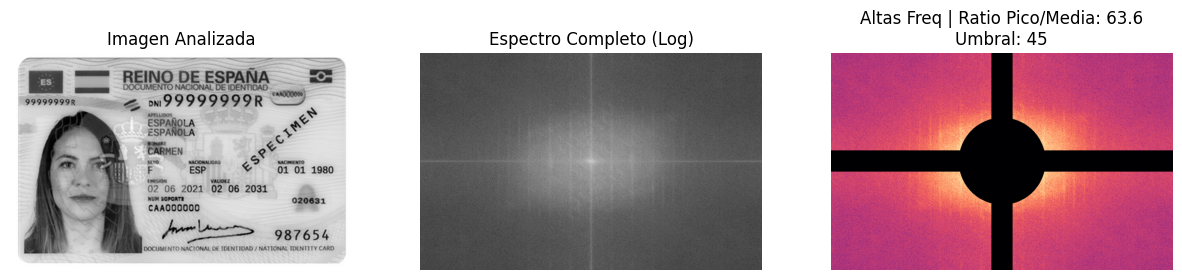


[1] SEGURIDAD HARDWARE
	Estado Moiré: ALERTA
	Peak Ratio (THRESHOLD: 45):   63.55

[2] LECTURA DE CARACTERES (MRZ)
    L1: IDESPCAA000000499999999R<<<<<<
    L2: 8001014F3106028ESP<<<<<<<<<<<1
    L3: ESPANOLA<ESPANOLA<<CARMEN<<<<<

[3] LECTURA ESTRUCTURADA (MRZ)
	tipo              : ID
	pais              : ESP
	soporte           : CAA000000
	dni               : 99999999R
	nacimiento        : 01/01/1980
	sexo              : F
	validez           : 02/06/2031
	nacionalidad      : ESP
	apellidos         : ESPANOLA ESPANOLA
	nombre            : CARMEN

[4] INTEGRIDAD DE DATOS (ICAO)
	Número Soporte:    VALID
	Fecha Nacimiento:  VALID
	Fecha Expiración:  VALID
	Suma de Control:   VALID

[5] VALIDACIÓN DE ATRIBUTOS
	[VALID] Vigencia Temporal : Vigencia coherente para edad (46 años).
		 - info: edad: 46, vigencia: 5
	[VALID] Ratio de Imagen   : Formato ISO correcto (1.57)
		 - info: ratio: 1.57, w: 1000, h: 636
	[VALID] Detección Facial  : Rostro detectado correctamente.
	[VALID] Firma      

In [114]:
for dni_path in TESTS_DIR.iterdir():
    if not dni_path.is_dir(): continue
    
    print(f"\n{'='*60}")
    print(f" ANALIZANDO DOCUMENTO: {dni_path.stem}")
    print(f"{'='*60}")

    # Inicialización de variables para asegurar disponibilidad en el cruce de datos
    viz_raw_structured = {}
    mrz_raw_lines = []
    front_path = None
    back_path = None

    try: 
        for side_path in dni_path.iterdir():
            if side_path.stem == "front":
                front_path = side_path

                # ANTISPOOFING
                spoof = AntiSpoofingValidation.detect_screen_moire(side_path, output_path=dni_path.stem, 
                                                                   threshold_ratio=moire_threshold_ratio, plot_debug=True)
                # VIZ
                viz_raw_structured = viz.process_front(side_path, word_confidence=viz_word_confidence) 
        
            elif side_path.stem == "back":
                back_path = side_path

                # MRZ
                mrz_raw_lines = mrz.get_mrz_montecarlo(side_path, dni_path.stem, iterations=montecarlo_iterations)
                mrz_raw_structured = MRZProcessor.mrz_structured_data(mrz_raw_lines)
            else:
                continue

        ################ VALIDACION ################
        # --- SEGURIDAD FÍSICA (ANTISPOOFING) ---
        spoof_pipeline(spoof)
        # --- EXTRACCIÓN Y CRUCE DE DATOS ---
        mrz_cv_lines, mrz_cv_structured = cv_pipeline(mrz_raw_lines, mrz_raw_structured, viz_raw_structured, cv_confidence_threshold)
        # --- INTEGRIDAD MATEMÁTICA ---
        checksums = icao_pipeline(mrz_cv_lines)
        # --- VALIDACIÓN BIOMÉTRICA Y LÓGICA ---
        results = data_pipeline(dni_path, front_path, back_path, mrz_cv_structured)

    except DNIError as e:
        _ = AntiSpoofingValidation.detect_screen_moire(side_path, output_path=dni_path.stem,
                                                       threshold_ratio=moire_threshold_ratio, plot_debug=True)
        print(f"\n{e}")
        print(f"\033[93m[!] Omitiendo análisis completo por fallo en reglas de negocio.\033[0m")
        continue

    # --- MOTOR DE VEREDICTO FINAL ---
    veredict_pipeline(spoof, checksums, results)

# Posibles Añadidos

- verificación lugar de nacimiento correcto
- verificación nacionalidad
- verificación número de equipo
- verificación del domicilio
- verificación del CAN (Clave numérica para sesión digital)
- verificación del CLI (CLI (Imagen láser cambiante) en bajo relieve)
- verificación de banderas

![front](data/to_add/DNI1_600.jpg)

![back](data/to_add/DNI2_600.jpg)